In [4]:
from helper import *

def efficiency_growth(df):
    length_sum = [0]
    pop_sum = [0]
    boundary = 1
    while boundary <= df.shape[0]:
        optimized = df[:boundary]
        length_sum.append(optimized['Li'].sum() - optimized['Sewer Length'].sum())
        pop_sum.append(optimized['Total Population'].sum() - optimized['Attended Population'].sum())
        boundary += 1
    return length_sum, pop_sum

def equality_growth(df, beta, step_size):
    length_sum = [0]
    pop_sum = [0]
    df['temp_Y'] = df['Sewer Length']
    df['temp_M'] = df['Attended Population']
    df['temp_k'] = df['temp_M'] / df['Total Population']
    df = df.sort_values(by=['temp_k'], ascending=True).reset_index()
    min_temp_k_index = 0

    while df.loc[0, 'temp_k'] < 1:

        # Find the correct value to increase the population by
        delta_Y = min(step_size, df.loc[min_temp_k_index, 'Ai'] * df.loc[min_temp_k_index, 'Total Population'] ** beta)
        df.loc[min_temp_k_index, 'temp_Y'] = df.loc[min_temp_k_index, 'temp_Y'] + delta_Y

        # Attending N more people in the city and seeing effects on Y and k
        delta_M = (df.loc[min_temp_k_index, 'temp_Y'] / df.loc[min_temp_k_index, 'Ai']) ** (1 / beta) - df.loc[min_temp_k_index, 'temp_M']
        df.loc[min_temp_k_index, 'temp_M'] = df.loc[min_temp_k_index, 'temp_M'] + delta_M
        df['temp_k'] = df['temp_M'] / df['Total Population']

        # Updating the current values for dM and dY
        pop_sum.append(pop_sum[-1] + delta_M)
        length_sum.append(length_sum[-1] + delta_Y)

        # Find the city to be expanded next
        min_temp_k_index = df['temp_k'].idxmin()

    return length_sum, pop_sum

def zipf_distribution(N_cities, s):
    population = []
    for i in range(N_cities):
        population.append(int(1000000 / (i + 1) ** s))
    return population

def get_zipf(beta, N_cities, s=1, A_i=np.exp(-4), step_size=10):
    zipf = {'Total Population': zipf_distribution(N_cities, s)}
    zipf = pd.DataFrame(data=zipf)

    # Adding other columns
    zipf['Sewer Length'] = 0
    zipf['Attended Population'] = 0
    zipf['Ai'] = A_i
    zipf['Li'] = zipf['Ai'] * (zipf['Total Population']) ** beta

    # Calling the functions
    a = efficiency_growth(zipf)
    b = equality_growth(zipf, beta, step_size)
    return a, b

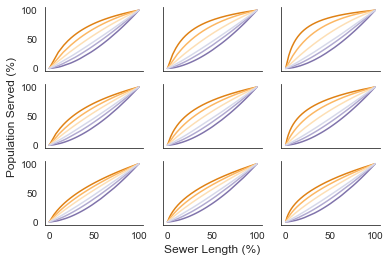

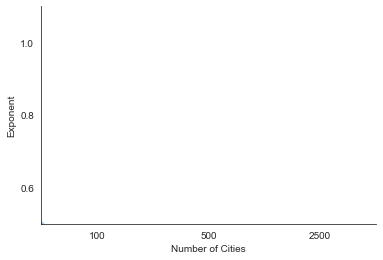

In [5]:
plot_zipf_distributions(save=False, data_path="../data/pickle/zipf_data", load_data=True)